# Time-Delay Filters

In [1]:
import jax
import jax.numpy as jnp

import matplotlib.pylab as plt

import WDM
from WDM.code.discrete_wavelet_transform import WDM

In [4]:
dt = 1.0

Nt = 32
Nf = 16
N = Nt*Nf

wdm = WDM.WDM_transform(dt=dt, Nf=Nf, N=N, q=8, calc_m0=True)

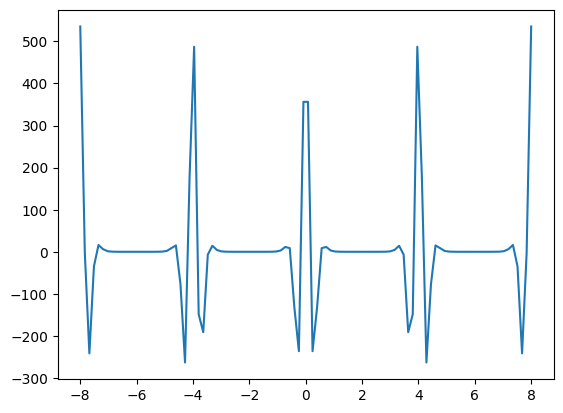

In [13]:
l = jnp.array([0])
delta  = jnp.linspace(-0.5*wdm.dT, 0.5*wdm.dT, 100)

wdm.build_time_delay_filter_interpolants(5, 100)

Tl = wdm.time_delay_filter_Tl(l, delta)[0]

plt.plot(delta, Tl)
plt.show()

In [12]:
Tl.shape

(100,)

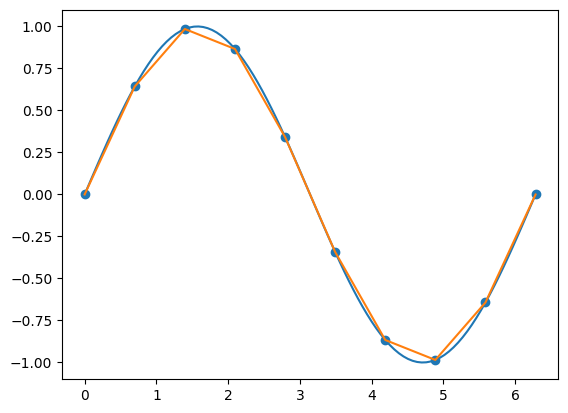

In [ ]:
from jax.scipy.interpolate import RegularGridInterpolator

xp = jnp.linspace(0, 2*jnp.pi, 10)
yp = jnp.sin(xp)

interpolant = RegularGridInterpolator((xp,), yp)

x = jnp.linspace(0, 2*jnp.pi, 100)
y = jnp.sin(x)

plt.plot(x, y)
plt.scatter(xp, yp)
plt.plot(x, interpolant(x))
plt.show()





In [ ]:
interpolant(jnp.array([1.]))

IndexError: tuple index out of range

In [ ]:
f0 = jnp.sin
f1 = jnp.cos
f2 = jnp.tan

x = jnp.array([1., 2., 3.])

def func(i, x):
    """
    i : array, int, shape=(a,)
    x : array, float, shape=(n,)

    y : array, float, shape=(a,n)
    """
    # Compute all functions on x
    results = jnp.stack([f0(x), f1(x), f2(x)])  # shape (3, n)
    # Index by i to select which function result for each row
    return results[i]  # shape (a, n)

def func2(i, x):
      funcs = [f0, f1, f2]
      def apply_func(idx):
          return jax.lax.switch(idx, funcs, x)
      return jax.vmap(apply_func)(i)


In [ ]:
i = jnp.array([0,1,2,0,1,2,2])

func(i, x)-func2(i, x)

Array([[0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.],
       [0., 0., 0.]], dtype=float64)